In [5]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/SeqToSeq"
import os
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

print(f"Working directory: {os.getcwd()}")
print(f"Files in directory: {os.listdir(PROJECT_DIR)}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/SeqToSeq
Files in directory: ['src_vocab.pkl', 'tgt_vocab.pkl', 'train_data.pkl', 'val_data.pkl', 'test_data.pkl', 'vanilla_rnn_best.pt', 'vanilla_rnn_losses.pkl', 'lstm_best.pt', 'lstm_losses.pkl', 'lstm_attention_losses.pkl', 'lstm_attention_best.pt', 'training_curves.png', 'attention_example_1.png', 'attention_example_2.png', 'attention_example_3.png', 'bleu_distribution.png', 'error_analysis_summary.csv', 'evaluation_results.pkl']


In [ ]:
!pip install datasets torchtext matplotlib seaborn nltk sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 13.2 MB/s eta 0:00:00


In [6]:
# Basic imports


import numpy as np
import pandas as pd
import os
import random
import re
import collections
from collections import Counter

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# HuggingFace dataset
from datasets import load_dataset

# For reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cpu


### Dataset Processing

In [7]:
data_set = load_dataset("Nan-Do/code-search-net-python")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-ee77a7de79eb2a(…):   0%|          | 0.00/155M [00:00<?, ?B/s]

data/train-00001-of-00004-648b3bede2edf6(…):   0%|          | 0.00/139M [00:00<?, ?B/s]

data/train-00002-of-00004-1dfd72b171e6b2(…):   0%|          | 0.00/153M [00:00<?, ?B/s]

data/train-00003-of-00004-184ab6d0e3c690(…):   0%|          | 0.00/151M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/455243 [00:00<?, ? examples/s]

In [ ]:
import pickle

# Configuration
MAX_DOCSTRING_LENGTH = 50
MAX_CODE_LENGTH = 80
NUM_TRAIN_SAMPLES = 10000
NUM_VAL_SAMPLES = 1000
NUM_TEST_SAMPLES = 1000

def tokenize(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip().split()

class Vocabulary:
    def __init__(self):
        # Special tokens
        self.PAD_TOKEN = "<pad>"
        self.UNK_TOKEN = "<unk>"
        self.SOS_TOKEN = "<sos>"
        self.EOS_TOKEN = "<eos>"

        self.word2idx = {
            self.PAD_TOKEN: 0,
            self.UNK_TOKEN: 1,
            self.SOS_TOKEN: 2,
            self.EOS_TOKEN: 3
        }

        self.idx2word = {
            0: self.PAD_TOKEN,
            1: self.UNK_TOKEN,
            2: self.SOS_TOKEN,
            3: self.EOS_TOKEN
        }

        self.word_count = {}
        self.n_words = 4  # Count special tokens

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word] = self.n_words
            self.idx2word[self.n_words] = word
            self.word_count[word] = 1
            self.n_words += 1
        else:
            if word not in [self.PAD_TOKEN, self.UNK_TOKEN, self.SOS_TOKEN, self.EOS_TOKEN]:
                self.word_count[word] += 1

    def sentence_to_indices(self, sentence, max_length):
        tokens = sentence.split()[:max_length]

        indices = [
            self.word2idx.get(word, self.word2idx[self.UNK_TOKEN])
            for word in tokens
        ]

        # Add <sos> and <eos>
        indices = (
            [self.word2idx[self.SOS_TOKEN]]
            + indices
            + [self.word2idx[self.EOS_TOKEN]]
        )

        return indices

    def indices_to_sentence(self, indices):
        words = []
        for idx in indices:
            word = self.idx2word.get(idx, self.UNK_TOKEN)

            if word in [self.PAD_TOKEN, self.SOS_TOKEN]:
                continue
            if word == self.EOS_TOKEN:
                break

            words.append(word)

        return " ".join(words)


def preprocess_data(dataset_split, num_samples):
    data = []

    for example in dataset_split:
        if len(data) >= num_samples:
            break

        try:
            doc_tokens = example.get("docstring_tokens", [])
            code_tokens = example.get("code_tokens", [])

            # Skip empty
            if not doc_tokens or not code_tokens:
                continue

            # Apply length filter
            if (len(doc_tokens) > 0 and len(doc_tokens) <= MAX_DOCSTRING_LENGTH and
                len(code_tokens) > 0 and len(code_tokens) <= MAX_CODE_LENGTH):
                data.append({
                    'docstring': ' '.join(doc_tokens),
                    'code': ' '.join(code_tokens)
                })

        except Exception as e:
            continue

    return data

# Preprocess data
print("Preprocessing data...")
total_samples_needed = NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES + NUM_TEST_SAMPLES
all_data = preprocess_data(data_set['train'], total_samples_needed)

print(f"Total samples collected: {len(all_data)}")

# Shuffle before splitting (
random.seed(SEED)
random.shuffle(all_data)

# Split data
train_data = all_data[:NUM_TRAIN_SAMPLES]
val_data = all_data[NUM_TRAIN_SAMPLES:NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES]
test_data = all_data[NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES:NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES + NUM_TEST_SAMPLES]

print(f"\nTrain samples: {len(train_data)}")
print(f"Val samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

if len(train_data) > 0:
    print(f"\nSample example:")
    print(f"Docstring: {train_data[0]['docstring'][:150]}...")
    print(f"Code: {train_data[0]['code'][:150]}...")

# Build vocabularies
print("\nBuilding vocabularies...")
src_vocab = Vocabulary()
tgt_vocab = Vocabulary()

for pair in train_data:
    src_vocab.add_sentence(pair['docstring'])
    tgt_vocab.add_sentence(pair['code'])

print(f"Source vocab size: {src_vocab.n_words}")
print(f"Target vocab size: {tgt_vocab.n_words}")

# Save vocabularies to Google Drive
with open(os.path.join(PROJECT_DIR, 'src_vocab.pkl'), 'wb') as f:
    pickle.dump(src_vocab, f)
with open(os.path.join(PROJECT_DIR, 'tgt_vocab.pkl'), 'wb') as f:
    pickle.dump(tgt_vocab, f)

# Save data splits
with open(os.path.join(PROJECT_DIR, 'train_data.pkl'), 'wb') as f:
    pickle.dump(train_data, f)
with open(os.path.join(PROJECT_DIR, 'val_data.pkl'), 'wb') as f:
    pickle.dump(val_data, f)
with open(os.path.join(PROJECT_DIR, 'test_data.pkl'), 'wb') as f:
    pickle.dump(test_data, f)

Preprocessing data...
Total samples collected: 12000

Train samples: 10000
Val samples: 1000
Test samples: 1000

Sample example:
Docstring: Returns a list of contexts this parameter is initialized on ....
Code: def list_ctx ( self ) : if self . _data is None : if self . _deferred_init : return self . _deferred_init [ 1 ] raise RuntimeError ( "Parameter '%s' h...

Building vocabularies...
Source vocab size: 10160
Target vocab size: 41128


In [ ]:
class CodeGenerationDataset(Dataset):
    def __init__(self, data, src_vocab, tgt_vocab):
        self.data = data
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        pair = self.data[idx]
        src_indices = self.src_vocab.sentence_to_indices(
            pair['docstring'], MAX_DOCSTRING_LENGTH)
        tgt_indices = self.tgt_vocab.sentence_to_indices(
            pair['code'], MAX_CODE_LENGTH)
        return torch.tensor(src_indices), torch.tensor(tgt_indices)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    src_lengths = [len(s) for s in src_batch]
    tgt_lengths = [len(t) for t in tgt_batch]

    max_src_len = max(src_lengths)
    max_tgt_len = max(tgt_lengths)

    src_padded = torch.zeros(len(batch), max_src_len, dtype=torch.long)
    tgt_padded = torch.zeros(len(batch), max_tgt_len, dtype=torch.long)

    for i, (src, tgt) in enumerate(zip(src_batch, tgt_batch)):
        src_padded[i, :len(src)] = src
        tgt_padded[i, :len(tgt)] = tgt

    return src_padded, tgt_padded, torch.tensor(src_lengths), torch.tensor(tgt_lengths)

# Create datasets
train_dataset = CodeGenerationDataset(train_data, src_vocab, tgt_vocab)
val_dataset = CodeGenerationDataset(val_data, src_vocab, tgt_vocab)
test_dataset = CodeGenerationDataset(test_data, src_vocab, tgt_vocab)

# Create dataloaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"DataLoaders created!")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

DataLoaders created!
Train batches: 313
Val batches: 32
Test batches: 32


### Model class definition

In [ ]:
# Model 1: Vanilla RNN
class EncoderRNN(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim):
        super(EncoderRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class DecoderRNN(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_dim):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, output_size)

    def forward(self, input, hidden):
        embedded = self.embedding(input)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.out(output)
        return prediction, hidden

class Seq2SeqRNN(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqRNN, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        encoder_outputs, hidden = self.encoder(src, src_lengths)

        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t, :] = output.squeeze(1)

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(2)
            input = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return outputs

# Model 2: LSTM
class EncoderLSTM(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim):
        super(EncoderLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell

class DecoderLSTM(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_dim):
        super(DecoderLSTM, self).__init__()
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, output_size)

    def forward(self, input, hidden, cell):
        embedded = self.embedding(input)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.out(output)
        return prediction, hidden, cell

class Seq2SeqLSTM(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqLSTM, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src, src_lengths)

        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t, :] = output.squeeze(1)

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(2)
            input = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return outputs

# Model 3: LSTM with Attention
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.Ua = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.Va = nn.Linear(hidden_dim * 2, 1)

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query).unsqueeze(1) + self.Ua(keys)))
        scores = scores.squeeze(2)

        attention_weights = torch.softmax(scores, dim=1)

        context = torch.bmm(attention_weights.unsqueeze(1), keys)
        context = context.squeeze(1)

        return context, attention_weights

class EncoderLSTMBidirectional(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim):
        super(EncoderLSTMBidirectional, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)

        # Concatenate forward and backward states
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1).unsqueeze(0)
        cell = torch.cat([cell[-2], cell[-1]], dim=1).unsqueeze(0)

        return outputs, hidden, cell

class DecoderLSTMAttention(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_dim, attention):
        super(DecoderLSTMAttention, self).__init__()
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=0)
        self.attention = attention
        self.lstm = nn.LSTM(embedding_dim + hidden_dim * 2, hidden_dim * 2, batch_first=True)
        self.out = nn.Linear(hidden_dim * 2, output_size)

    def forward(self, input, hidden, cell, encoder_outputs):
        embedded = self.embedding(input)

        context, attention_weights = self.attention(hidden.squeeze(0), encoder_outputs)

        lstm_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

        prediction = self.out(output)

        return prediction, hidden, cell, attention_weights

class Seq2SeqLSTMAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqLSTMAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)
        attentions = torch.zeros(batch_size, tgt_len, src.shape[1]).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src, src_lengths)

        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden, cell, attention_weights = self.decoder(
                input, hidden, cell, encoder_outputs)
            outputs[:, t, :] = output.squeeze(1)
            attentions[:, t, :] = attention_weights

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(2)
            input = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return outputs, attentions

In [ ]:
import time
from tqdm import tqdm

def train_epoch(model, iterator, optimizer, criterion, clip, model_type='rnn'):
    model.train()
    epoch_loss = 0

    for src, tgt, src_lengths, tgt_lengths in tqdm(iterator, desc="Training"):
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()

        if model_type == 'attention':
            output, _ = model(src, tgt, src_lengths, teacher_forcing_ratio=0.5)
        else:
            output = model(src, tgt, src_lengths, teacher_forcing_ratio=0.5)

        output = output[:, 1:].reshape(-1, output.shape[-1])
        tgt = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

def evaluate(model, iterator, criterion, model_type='rnn'):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, tgt, src_lengths, tgt_lengths in iterator:
            src, tgt = src.to(device), tgt.to(device)

            if model_type == 'attention':
                output, _ = model(src, tgt, src_lengths, teacher_forcing_ratio=0)
            else:
                output = model(src, tgt, src_lengths, teacher_forcing_ratio=0)

            output = output[:, 1:].reshape(-1, output.shape[-1])
            tgt = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

def train_model(model, train_loader, val_loader, optimizer, criterion,
                n_epochs, model_name, model_type='rnn'):
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []

    for epoch in range(n_epochs):
        start_time = time.time()

        train_loss = train_epoch(model, train_loader, optimizer, criterion, 1, model_type)
        val_loss = evaluate(model, val_loader, criterion, model_type)

        end_time = time.time()
        epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # Save to Google Drive
            torch.save(model.state_dict(), os.path.join(PROJECT_DIR, f'{model_name}_best.pt'))

        print(f'Epoch: {epoch+1:02} | Time: {epoch_mins:.0f}m {epoch_secs:.0f}s')
        print(f'\tTrain Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f}')

    # Save loss history
    with open(os.path.join(PROJECT_DIR, f'{model_name}_losses.pkl'), 'wb') as f:
        pickle.dump({'train': train_losses, 'val': val_losses}, f)

    return train_losses, val_losses

### Model Training

In [ ]:
import torch.optim as optim

EMBEDDING_DIM = 256
HIDDEN_DIM = 256
N_EPOCHS = 20
LEARNING_RATE = 0.001

INPUT_DIM = src_vocab.n_words
OUTPUT_DIM = tgt_vocab.n_words

criterion = nn.CrossEntropyLoss(ignore_index=0)

# Model 1: Vanilla RNN
print("\n" + "="*30)
print("Training Vanilla RNN Seq2Seq")
print("="*30)

enc_rnn = EncoderRNN(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
dec_rnn = DecoderRNN(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
model_rnn = Seq2SeqRNN(enc_rnn, dec_rnn, device).to(device)

optimizer_rnn = optim.Adam(model_rnn.parameters(), lr=LEARNING_RATE)
train_losses_rnn, val_losses_rnn = train_model(
    model_rnn, train_loader, val_loader, optimizer_rnn, criterion,
    N_EPOCHS, 'vanilla_rnn', 'rnn')

# Model 2: LSTM
print("\n" + "="*30)
print("Training LSTM Seq2Seq")
print("="*30)

enc_lstm = EncoderLSTM(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
dec_lstm = DecoderLSTM(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
model_lstm = Seq2SeqLSTM(enc_lstm, dec_lstm, device).to(device)

optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)
train_losses_lstm, val_losses_lstm = train_model(
    model_lstm, train_loader, val_loader, optimizer_lstm, criterion,
    N_EPOCHS, 'lstm', 'lstm')




Training Vanilla RNN Seq2Seq


Training: 100%|██████████| 313/313 [04:24<00:00,  1.18it/s]


Epoch: 01 | Time: 4m 36s
	Train Loss: 5.684 | Val Loss: 5.920


Training: 100%|██████████| 313/313 [04:24<00:00,  1.18it/s]


Epoch: 02 | Time: 4m 36s
	Train Loss: 4.953 | Val Loss: 6.223


...

Training: 100%|██████████| 313/313 [05:27<00:00,  1.04s/it]


Epoch: 17 | Time: 5m 40s
	Train Loss: 1.954 | Val Loss: 6.662


Training: 100%|██████████| 313/313 [05:25<00:00,  1.04s/it]


Epoch: 18 | Time: 5m 38s
	Train Loss: 1.847 | Val Loss: 6.786


Training:  19%|█▉        | 61/313 [01:03<04:24,  1.05s/it]

In [ ]:
# fixing reconnecting issue
import torch.optim as optim

EMBEDDING_DIM = 256
HIDDEN_DIM = 256
N_EPOCHS = 20
LEARNING_RATE = 0.001

INPUT_DIM = src_vocab.n_words
OUTPUT_DIM = tgt_vocab.n_words

criterion = nn.CrossEntropyLoss(ignore_index=0)


# Model 3: LSTM with Attention
print("\n" + "="*30)
print("Training LSTM with Attention")
print("="*30)

enc_lstm_bi = EncoderLSTMBidirectional(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
attention = BahdanauAttention(HIDDEN_DIM).to(device)
dec_lstm_attn = DecoderLSTMAttention(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, attention).to(device)
model_attention = Seq2SeqLSTMAttention(enc_lstm_bi, dec_lstm_attn, device).to(device)

optimizer_attention = optim.Adam(model_attention.parameters(), lr=LEARNING_RATE)
train_losses_attn, val_losses_attn = train_model(
    model_attention, train_loader, val_loader, optimizer_attention, criterion,
    N_EPOCHS, 'lstm_attention', 'attention')

print("\n" + "="*30)
print("ALL MODELS TRAINED AND SAVED TO GOOGLE DRIVE!")
print("="*30)


Training LSTM with Attention


Training: 100%|██████████| 313/313 [05:26<00:00,  1.04s/it]


Epoch: 01 | Time: 5m 39s
	Train Loss: 5.703 | Val Loss: 5.864


Training: 100%|██████████| 313/313 [05:27<00:00,  1.05s/it]


Epoch: 02 | Time: 5m 40s
	Train Loss: 4.924 | Val Loss: 6.006


...

Epoch: 18 | Time: 5m 44s
	Train Loss: 1.766 | Val Loss: 6.820


Training: 100%|██████████| 313/313 [05:32<00:00,  1.06s/it]


Epoch: 19 | Time: 5m 45s
	Train Loss: 1.635 | Val Loss: 6.852


Training: 100%|██████████| 313/313 [05:31<00:00,  1.06s/it]


Epoch: 20 | Time: 5m 44s
	Train Loss: 1.541 | Val Loss: 6.992

ALL MODELS TRAINED AND SAVED TO GOOGLE DRIVE!


In [8]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

PROJECT_DIR = "/content/drive/MyDrive/SeqToSeq"
import os
os.chdir(PROJECT_DIR)

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pickle
from tqdm import tqdm

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Configuration
MAX_DOCSTRING_LENGTH = 50
MAX_CODE_LENGTH = 80
EMBEDDING_DIM = 256
HIDDEN_DIM = 256

class Vocabulary:
    def __init__(self):
        # Special tokens
        self.PAD_TOKEN = "<pad>"
        self.UNK_TOKEN = "<unk>"
        self.SOS_TOKEN = "<sos>"
        self.EOS_TOKEN = "<eos>"

        self.word2idx = {
            self.PAD_TOKEN: 0,
            self.UNK_TOKEN: 1,
            self.SOS_TOKEN: 2,
            self.EOS_TOKEN: 3
        }

        self.idx2word = {
            0: self.PAD_TOKEN,
            1: self.UNK_TOKEN,
            2: self.SOS_TOKEN,
            3: self.EOS_TOKEN
        }

        self.word_count = {}
        self.n_words = 4  # Count special tokens

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word] = self.n_words
            self.idx2word[self.n_words] = word
            self.word_count[word] = 1
            self.n_words += 1
        else:
            if word not in [self.PAD_TOKEN, self.UNK_TOKEN, self.SOS_TOKEN, self.EOS_TOKEN]:
                self.word_count[word] += 1

    def sentence_to_indices(self, sentence, max_length):
        tokens = sentence.split()[:max_length]

        indices = [
            self.word2idx.get(word, self.word2idx[self.UNK_TOKEN])
            for word in tokens
        ]

        # Add <sos> and <eos>
        indices = (
            [self.word2idx[self.SOS_TOKEN]]
            + indices
            + [self.word2idx[self.EOS_TOKEN]]
        )

        return indices

    def indices_to_sentence(self, indices):
        words = []
        for idx in indices:
            word = self.idx2word.get(idx, self.UNK_TOKEN)

            if word in [self.PAD_TOKEN, self.SOS_TOKEN]:
                continue
            if word == self.EOS_TOKEN:
                break

            words.append(word)

        return " ".join(words)

# Now load vocabularies
with open(os.path.join(PROJECT_DIR, 'src_vocab.pkl'), 'rb') as f:
    src_vocab = pickle.load(f)
with open(os.path.join(PROJECT_DIR, 'tgt_vocab.pkl'), 'rb') as f:
    tgt_vocab = pickle.load(f)

# Load data splits
with open(os.path.join(PROJECT_DIR, 'train_data.pkl'), 'rb') as f:
    train_data = pickle.load(f)
with open(os.path.join(PROJECT_DIR, 'val_data.pkl'), 'rb') as f:
    val_data = pickle.load(f)
with open(os.path.join(PROJECT_DIR, 'test_data.pkl'), 'rb') as f:
    test_data = pickle.load(f)

print(f"Vocabularies and data loaded!")
print(f"Source vocab size: {src_vocab.n_words}")
print(f"Target vocab size: {tgt_vocab.n_words}")
print(f"Test samples: {len(test_data)}")

INPUT_DIM = src_vocab.n_words
OUTPUT_DIM = tgt_vocab.n_words



Mounted at /content/drive
Using device: cpu
Vocabularies and data loaded!
Source vocab size: 10160
Target vocab size: 41128
Test samples: 1000


In [9]:
# all model classes
# Model 1: Vanilla RNN
class EncoderRNN(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim):
        super(EncoderRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class DecoderRNN(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_dim):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, output_size)

    def forward(self, input, hidden):
        embedded = self.embedding(input)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.out(output)
        return prediction, hidden

class Seq2SeqRNN(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqRNN, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src, src_lengths)
        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t, :] = output.squeeze(1)
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(2)
            input = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return outputs

# Model 2: LSTM
class EncoderLSTM(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim):
        super(EncoderLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell

class DecoderLSTM(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_dim):
        super(DecoderLSTM, self).__init__()
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, output_size)

    def forward(self, input, hidden, cell):
        embedded = self.embedding(input)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.out(output)
        return prediction, hidden, cell

class Seq2SeqLSTM(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqLSTM, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)
        encoder_outputs, hidden, cell = self.encoder(src, src_lengths)
        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t, :] = output.squeeze(1)
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(2)
            input = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return outputs

# Model 3: LSTM with Attention
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.Ua = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.Va = nn.Linear(hidden_dim * 2, 1)

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query).unsqueeze(1) + self.Ua(keys)))
        scores = scores.squeeze(2)
        attention_weights = torch.softmax(scores, dim=1)
        context = torch.bmm(attention_weights.unsqueeze(1), keys)
        context = context.squeeze(1)
        return context, attention_weights

class EncoderLSTMBidirectional(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim):
        super(EncoderLSTMBidirectional, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1).unsqueeze(0)
        cell = torch.cat([cell[-2], cell[-1]], dim=1).unsqueeze(0)
        return outputs, hidden, cell

class DecoderLSTMAttention(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_dim, attention):
        super(DecoderLSTMAttention, self).__init__()
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=0)
        self.attention = attention
        self.lstm = nn.LSTM(embedding_dim + hidden_dim * 2, hidden_dim * 2, batch_first=True)
        self.out = nn.Linear(hidden_dim * 2, output_size)

    def forward(self, input, hidden, cell, encoder_outputs):
        embedded = self.embedding(input)
        context, attention_weights = self.attention(hidden.squeeze(0), encoder_outputs)
        lstm_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.out(output)
        return prediction, hidden, cell, attention_weights

class Seq2SeqLSTMAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqLSTMAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)
        attentions = torch.zeros(batch_size, tgt_len, src.shape[1]).to(self.device)
        encoder_outputs, hidden, cell = self.encoder(src, src_lengths)
        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden, cell, attention_weights = self.decoder(
                input, hidden, cell, encoder_outputs)
            outputs[:, t, :] = output.squeeze(1)
            attentions[:, t, :] = attention_weights
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(2)
            input = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return outputs, attentions

print("All model classes are defined!")

# Recreate model instances
enc_rnn = EncoderRNN(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
dec_rnn = DecoderRNN(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
model_rnn = Seq2SeqRNN(enc_rnn, dec_rnn, device).to(device)

enc_lstm = EncoderLSTM(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
dec_lstm = DecoderLSTM(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
model_lstm = Seq2SeqLSTM(enc_lstm, dec_lstm, device).to(device)

enc_lstm_bi = EncoderLSTMBidirectional(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
attention = BahdanauAttention(HIDDEN_DIM).to(device)
dec_lstm_attn = DecoderLSTMAttention(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, attention).to(device)
model_attention = Seq2SeqLSTMAttention(enc_lstm_bi, dec_lstm_attn, device).to(device)

print("Model instances created!")

# Load trained weights from Google Drive
print("\nLoading trained model weights...")
model_rnn.load_state_dict(torch.load(os.path.join(PROJECT_DIR, 'vanilla_rnn_best.pt'), map_location=device))
model_lstm.load_state_dict(torch.load(os.path.join(PROJECT_DIR, 'lstm_best.pt'), map_location=device))
model_attention.load_state_dict(torch.load(os.path.join(PROJECT_DIR, 'lstm_attention_best.pt'), map_location=device))

print("Models are loaded!")


All model classes are defined!
Model instances created!

Loading trained model weights...
Models are loaded!


In [2]:
!pip install sacrebleu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.8 MB/s eta 0:00:00


### Evaluatuion

In [10]:
#evaluation mterics
from sacrebleu.metrics import BLEU

PAD_IDX = tgt_vocab.word2idx["<pad>"]
SOS_IDX = tgt_vocab.word2idx["<sos>"]
EOS_IDX = tgt_vocab.word2idx["<eos>"]


def translate_sentence(model, sentence, src_vocab, tgt_vocab, device, max_length=80, model_type='rnn'):
    model.eval()

    tokens = sentence.split()
    indices = src_vocab.sentence_to_indices(
        ' '.join(tokens), MAX_DOCSTRING_LENGTH
    )

    src_tensor = torch.tensor(indices).unsqueeze(0).to(device)
    src_length = torch.tensor([len(indices)]).to(device)

    outputs = [SOS_IDX]
    attentions = []

    with torch.no_grad():

        if model_type == 'attention':
            encoder_outputs, hidden, cell = model.encoder(src_tensor, src_length)

            for _ in range(max_length):
                input_tensor = torch.tensor([[outputs[-1]]]).to(device)

                output, hidden, cell, attention = model.decoder(
                    input_tensor, hidden, cell, encoder_outputs
                )

                pred_token = output.argmax(2).item()
                outputs.append(pred_token)

                attentions.append(attention.squeeze(0).cpu().numpy())

                if pred_token == EOS_IDX:
                    break

            return outputs[1:], np.array(attentions)

        elif model_type == 'lstm':
            encoder_outputs, hidden, cell = model.encoder(src_tensor, src_length)

            for _ in range(max_length):
                input_tensor = torch.tensor([[outputs[-1]]]).to(device)

                output, hidden, cell = model.decoder(input_tensor, hidden, cell)

                pred_token = output.argmax(2).item()
                outputs.append(pred_token)

                if pred_token == EOS_IDX:
                    break

            return outputs[1:], None

        else:  # RNN
            encoder_outputs, hidden = model.encoder(src_tensor, src_length)

            for _ in range(max_length):
                input_tensor = torch.tensor([[outputs[-1]]]).to(device)

                output, hidden = model.decoder(input_tensor, hidden)

                pred_token = output.argmax(2).item()
                outputs.append(pred_token)

                if pred_token == EOS_IDX:
                    break

            return outputs[1:], None


def calculate_bleu(model, test_data, src_vocab, tgt_vocab,
                   device, model_type='rnn', num_samples=100):

    bleu = BLEU(force=True)
    references = [[]]
    hypotheses = []

    for pair in tqdm(test_data, desc="Calculating BLEU"):

        src = pair['docstring']
        tgt = pair['code']

        pred_indices, _ = translate_sentence(
            model, src, src_vocab, tgt_vocab,
            device, model_type=model_type
        )

        pred_tokens = [
            tgt_vocab.idx2word.get(idx, "<unk>")
            for idx in pred_indices
            if idx not in [PAD_IDX, SOS_IDX, EOS_IDX]
        ]

        hypotheses.append(" ".join(pred_tokens))
        references[0].append(tgt)

    score = bleu.corpus_score(hypotheses, references)
    return score.score

def calculate_exact_match(model, test_data, src_vocab, tgt_vocab,
                          device, model_type='rnn', num_samples=100):

    exact_matches = 0

    for pair in tqdm(test_data, desc="Calculating Exact Match"):

        src = pair['docstring']
        tgt = pair['code']

        pred_indices, _ = translate_sentence(
            model, src, src_vocab, tgt_vocab,
            device, model_type=model_type
        )

        pred_tokens = [
            tgt_vocab.idx2word.get(idx, "<unk>")
            for idx in pred_indices
            if idx not in [PAD_IDX, SOS_IDX, EOS_IDX]
        ]

        if " ".join(pred_tokens) == tgt:
            exact_matches += 1

    return (exact_matches / num_samples) * 100



def calculate_token_accuracy(model, test_data, src_vocab, tgt_vocab, device, model_type='rnn'):
    total_tokens = 0
    correct_tokens = 0

    for pair in tqdm(test_data, desc="Calculating Token Accuracy"):
        src = pair['docstring']
        tgt = pair['code'].split()  # reference tokens

        pred_indices, _ = translate_sentence(model, src, src_vocab, tgt_vocab, device, model_type=model_type)

        # Convert predicted indices to tokens, skipping SOS/EOS
        pred_tokens = [
            tgt_vocab.idx2word.get(idx, '')
            for idx in pred_indices
            if idx not in [SOS_IDX, EOS_IDX]
        ]


        for t_pred, t_ref in zip(pred_tokens, tgt):
            if t_pred == t_ref:
                correct_tokens += 1
        total_tokens += len(tgt)

    return (correct_tokens / total_tokens) * 100


In [11]:
model_rnn.load_state_dict(
    torch.load(os.path.join(PROJECT_DIR, 'vanilla_rnn_best.pt'), map_location=device)
)
model_lstm.load_state_dict(
    torch.load(os.path.join(PROJECT_DIR, 'lstm_best.pt'), map_location=device)
)
model_attention.load_state_dict(
    torch.load(os.path.join(PROJECT_DIR, 'lstm_attention_best.pt'), map_location=device)
)

print("All models loaded successfully!")


# ----- BLEU SCORES -----
bleu_rnn = calculate_bleu(model_rnn, test_data, src_vocab, tgt_vocab, device, 'rnn')
bleu_lstm = calculate_bleu(model_lstm, test_data, src_vocab, tgt_vocab, device, 'lstm')
bleu_attention = calculate_bleu(model_attention, test_data, src_vocab, tgt_vocab, device, 'attention')

# ----- EXACT MATCH -----
em_rnn = calculate_exact_match(model_rnn, test_data, src_vocab, tgt_vocab, device, 'rnn')
em_lstm = calculate_exact_match(model_lstm, test_data, src_vocab, tgt_vocab, device, 'lstm')
em_attention = calculate_exact_match(model_attention, test_data, src_vocab, tgt_vocab, device, 'attention')

# ----- TOKEN-LEVEL ACCURACY -----
token_acc_rnn = calculate_token_accuracy(model_rnn, test_data, src_vocab, tgt_vocab, device, 'rnn')
token_acc_lstm = calculate_token_accuracy(model_lstm, test_data, src_vocab, tgt_vocab, device, 'lstm')
token_acc_attention = calculate_token_accuracy(model_attention, test_data, src_vocab, tgt_vocab, device, 'attention')

# ==============================
# PRINT FORMATTED RESULTS
# ==============================
print("\n" + "="*30)
print("FINAL EVALUATION RESULTS")
print("="*30)

print(f"{'Model':<25} {'BLEU Score':<15} {'Exact Match (%)':<20} {'Token Acc (%)':<15}")
print("-"*60)

print(f"{'Vanilla RNN':<25} {bleu_rnn:<12.2f} {em_rnn:<18.2f} {token_acc_rnn:<15.2f}")
print(f"{'LSTM':<25} {bleu_lstm:<12.2f} {em_lstm:<18.2f} {token_acc_lstm:<15.2f}")
print(f"{'LSTM + Attention':<25} {bleu_attention:<12.2f} {em_attention:<18.2f} {token_acc_attention:<15.2f}")

print("="*60)

eval_results = {
    'bleu': {
        'rnn': bleu_rnn,
        'lstm': bleu_lstm,
        'attention': bleu_attention
    },
    'exact_match': {
        'rnn': em_rnn,
        'lstm': em_lstm,
        'attention': em_attention
    },
    'token_accuracy': {
        'rnn': token_acc_rnn,
        'lstm': token_acc_lstm,
        'attention': token_acc_attention
    }
}

with open(os.path.join(PROJECT_DIR, 'evaluation_results.pkl'), 'wb') as f:
    pickle.dump(eval_results, f)

print("Evaluation results saved successfully!")


All models loaded successfully!


Calculating Token Accuracy: 100%|██████████| 1000/1000 [09:11<00:00,  1.81it/s]



FINAL EVALUATION RESULTS
Model                     BLEU Score      Exact Match (%)      Token Acc (%)  
------------------------------------------------------------
Vanilla RNN               0.18         0.00               9.26           
LSTM                      0.79         0.00               10.19          
LSTM + Attention          2.30         0.00               10.96          
Evaluation results saved successfully!


### Visualisations

 Training losses loaded from Google Drive!


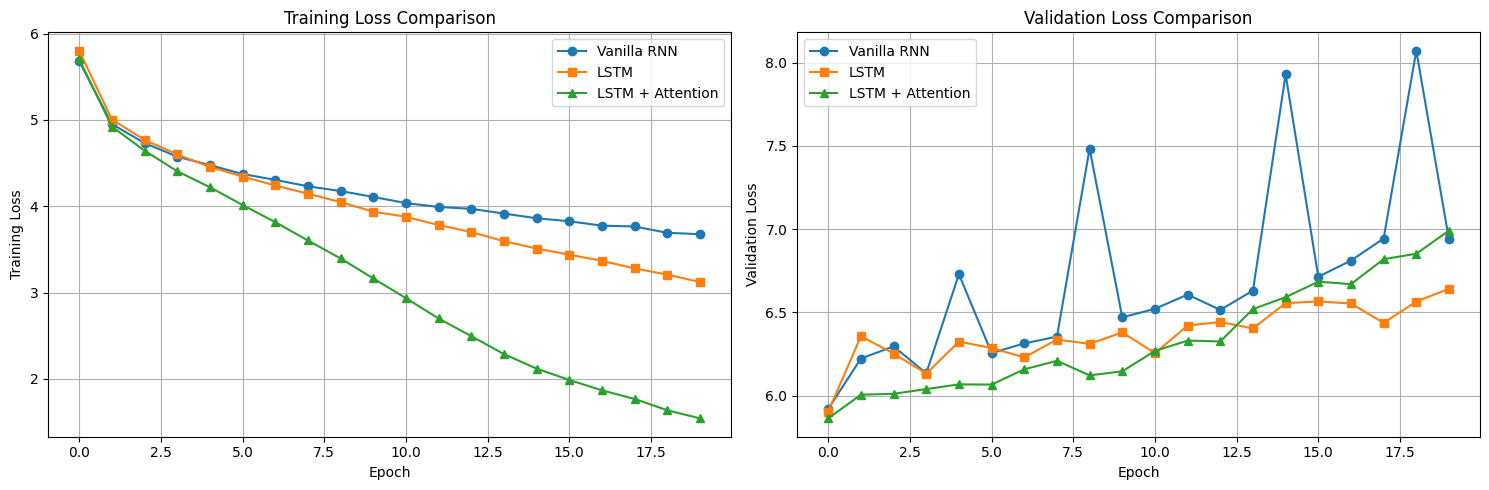

 Training curves saved to Google Drive!


In [ ]:
# Visualizations

with open(os.path.join(PROJECT_DIR, 'vanilla_rnn_losses.pkl'), 'rb') as f:
    rnn_losses = pickle.load(f)
    train_losses_rnn = rnn_losses['train']
    val_losses_rnn = rnn_losses['val']

with open(os.path.join(PROJECT_DIR, 'lstm_losses.pkl'), 'rb') as f:
    lstm_losses = pickle.load(f)
    train_losses_lstm = lstm_losses['train']
    val_losses_lstm = lstm_losses['val']

with open(os.path.join(PROJECT_DIR, 'lstm_attention_losses.pkl'), 'rb') as f:
    attn_losses = pickle.load(f)
    train_losses_attn = attn_losses['train']
    val_losses_attn = attn_losses['val']

print(" Training losses loaded from Google Drive!")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_losses_rnn, label='Vanilla RNN', marker='o')
axes[0].plot(train_losses_lstm, label='LSTM', marker='s')
axes[0].plot(train_losses_attn, label='LSTM + Attention', marker='^')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(val_losses_rnn, label='Vanilla RNN', marker='o')
axes[1].plot(val_losses_lstm, label='LSTM', marker='s')
axes[1].plot(val_losses_attn, label='LSTM + Attention', marker='^')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Validation Loss Comparison')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'training_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print(" Training curves saved to Google Drive!")

### bleu distribution on test code

In [7]:
# bleu distribution on test code

from sacrebleu.metrics import BLEU
from tqdm import tqdm

def calculate_per_example_bleu(model, test_data, src_vocab, tgt_vocab, device, model_type='rnn'):
    bleu = BLEU()
    per_example_scores = []

    for pair in tqdm(test_data, desc=f"Calculating per-example BLEU ({model_type})"):
        src = pair['docstring']
        tgt = pair['code']
        print(f"Source: {src}")
        print(f"Target: {tgt}")

        pred_indices, _ = translate_sentence(model, src, src_vocab, tgt_vocab, device, model_type=model_type)
        pred_tokens = [tgt_vocab.idx2word.get(idx, '') for idx in pred_indices if idx not in [SOS_IDX, EOS_IDX]]

        score = bleu.sentence_score(' '.join(pred_tokens), [tgt]).score
        per_example_scores.append(score)

    return per_example_scores


In [9]:
####### mistakenly this cell is run twice. in the second time, i stopped executing this cell.

bleu_rnn_scores = calculate_per_example_bleu(model_rnn, test_data, src_vocab, tgt_vocab, device, 'rnn')
bleu_lstm_scores = calculate_per_example_bleu(model_lstm, test_data, src_vocab, tgt_vocab, device, 'lstm')
bleu_attn_scores = calculate_per_example_bleu(model_attention, test_data, src_vocab, tgt_vocab, device, 'attention')

all_res = {
    'Vanilla RNN': {'bleu_scores': bleu_rnn_scores},
    'LSTM': {'bleu_scores': bleu_lstm_scores},
    'LSTM + Attention': {'bleu_scores': bleu_attn_scores}
}

names = ['Vanilla RNN', 'LSTM', 'LSTM + Attention']
colors = ['skyblue', 'lightgreen', 'lightcoral']

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))

bp = ax.boxplot(
    [all_res[n]['bleu_scores'] for n in names],
    labels=names,
    patch_artist=True,
    medianprops=dict(color='black', lw=2)
)

for p, c in zip(bp['boxes'], colors):
    p.set_facecolor(c)
    p.set_alpha(0.6)

ax.set(ylabel='BLEU Score', title='BLEU Score Distribution per Model')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'bleu_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()


Calculating per-example BLEU (rnn):   0%|          | 1/1000 [00:00<01:46,  9.41it/s]

Source: Make a character or block device called targetpath .
Target: def makedev ( self , tarinfo , targetpath ) : if not hasattr ( os , "mknod" ) or not hasattr ( os , "makedev" ) : raise ExtractError ( "special devices not supported by system" ) mode = tarinfo . mode if tarinfo . isblk ( ) : mode |= stat . S_IFBLK else : mode |= stat . S_IFCHR os . mknod ( targetpath , mode , os . makedev ( tarinfo . devmajor , tarinfo . devminor ) )
Source: Sort label names putting well - known resource labels first .
Target: def _sorted_resource_labels ( labels ) : head = [ label for label in TOP_RESOURCE_LABELS if label in labels ] tail = sorted ( label for label in labels if label not in TOP_RESOURCE_LABELS ) return head + tail


Calculating per-example BLEU (rnn):   0%|          | 3/1000 [00:00<01:50,  9.05it/s]

Source: : type root : TreeNode : type p : TreeNode : type q : TreeNode : rtype : TreeNode
Target: def lca ( root , p , q ) : if root is None or root is p or root is q : return root left = lca ( root . left , p , q ) right = lca ( root . right , p , q ) if left is not None and right is not None : return root return left if left else right
Source: Factory : construct an access entry given its API representation
Target: def from_api_repr ( cls , resource ) : entry = resource . copy ( ) role = entry . pop ( "role" , None ) entity_type , entity_id = entry . popitem ( ) if len ( entry ) != 0 : raise ValueError ( "Entry has unexpected keys remaining." , entry ) return cls ( role , entity_type , entity_id )


Calculating per-example BLEU (rnn):   0%|          | 5/1000 [00:00<01:48,  9.20it/s]

...

Calculating per-example BLEU (rnn):   9%|▉         | 93/1000 [00:10<01:35,  9.47it/s]

Source: list or watch objects of kind PodSecurityPolicy This method makes a synchronous HTTP request by default . To make an asynchronous HTTP request please pass async_req = True >>> thread = api . list_pod_security_policy ( async_req = True ) >>> result = thread . get ()
Target: def list_pod_security_policy ( self , * * kwargs ) : kwargs [ '_return_http_data_only' ] = True if kwargs . get ( 'async_req' ) : return self . list_pod_security_policy_with_http_info ( * * kwargs ) else : ( data ) = self . list_pod_security_policy_with_http_info ( * * kwargs ) return data
Source: Predict values for a single data point or an RDD of points using the model trained .
Target: def predict ( self , x ) : if isinstance ( x , RDD ) : return x . map ( lambda v : self . predict ( v ) ) x = _convert_to_vector ( x ) margin = self . weights . dot ( x ) + self . intercept if self . _threshold is None : return margin else : return 1 if margin > self . _threshold else 0


Calculating per-example BLEU (rnn):   9%|▉         | 94/1000 [00:11<01:47,  8.44it/s]

Source: Retrieve the Config in fpath .
Target: def get ( cls , fpath = None , create_missing = True ) : fpath = _expand_path ( fpath or cls . DEFAULT_CONFIG_PATH ) if not fpath . exists ( ) and create_missing : cls . create ( fpath ) assert fpath . exists ( ) , f'Could not find config at: {fpath}. Please create' with open ( fpath , 'r' ) as yaml_file : return yaml . safe_load ( yaml_file )


KeyboardInterrupt: 

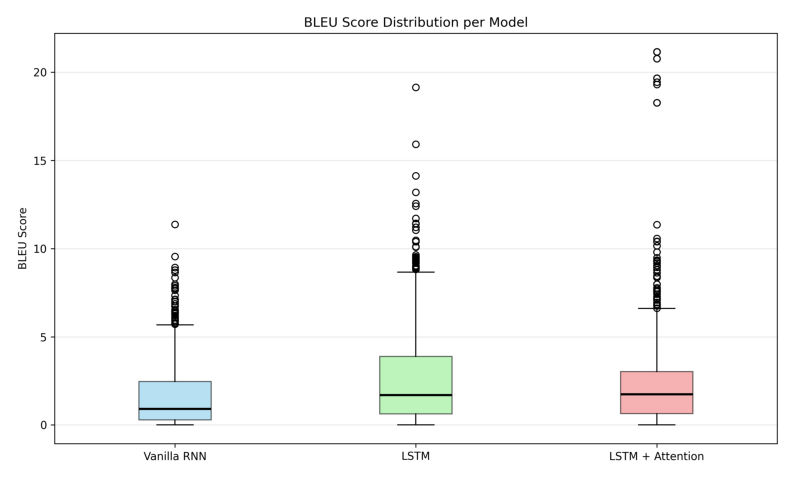

In [6]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_path = os.path.join(PROJECT_DIR, 'bleu_distribution.png')

img = mpimg.imread(img_path)
plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis('off')
plt.show()


### error

In [25]:


import ast
from collections import defaultdict

# ==============================
# 3️⃣ Types of Errors Analysis
# ==============================

def analyze_code_errors(pred_code, ref_code):
    """
    Analyze errors in a predicted Python code string.
    Returns counts for:
    - Syntax errors
    - Indentation errors
    - Incorrect operators/variables
    """

    samples = [
        {'reference': ref_code, 'generated': pred_code}
    ]
    syntax_errors = 0
    missing_indentation = 0; incorrect_operators = 0 ; missing_tokens = 0;extra_tokens = 0; total_errors = 0;
    ops = {'+','-','*','/','==','!=','>=','<=','>','<','and','or','not','in','is'}
    for s in samples:
        r, g = s['reference'], s['generated']
        if r==g: continue
        total_errors += 1
        if 'INDENT' in r and 'INDENT' not in g: missing_indentation += 1
        if {t for t in r.split() if t in ops} != {t for t in g.split() if t in ops}: incorrect_operators += 1
        rl, gl = len(r.split()), len(g.split())
        if gl<rl: missing_tokens += 1
        elif gl>rl: extra_tokens += 1
        try: compile(g.replace('NEWLINE','\n').replace('INDENT','    '),'<s>','exec')
        except SyntaxError: syntax_errors += 1

    return syntax_errors, missing_indentation, incorrect_operators, missing_tokens, extra_tokens, total_errors


error_summary = defaultdict(lambda: {'syntax_errors':0,'missing_indentation':0,'incorrect_operators':0,'missing_tokens':0,'extra_tokens':0,'total_errors':0})

for model_name, model, mtype in [
    ('Vanilla RNN', model_rnn, 'rnn'),
    ('LSTM', model_lstm, 'lstm'),
    ('LSTM + Attention', model_attention, 'attention')
]:
    for example in tqdm(test_data[:100], desc=f"Analyzing errors for {model_name}"):
        src = example['docstring']
        tgt = example['code']

        pred_indices, _ = translate_sentence(model, src, src_vocab, tgt_vocab, device, model_type=mtype)
        pred_tokens = [tgt_vocab.idx2word.get(idx, '') for idx in pred_indices if idx not in [SOS_IDX, EOS_IDX]]
        pred_code = ' '.join(pred_tokens)

        syntax_err, missing_ind, in_oper, missing_t, extra_t, total_errors = analyze_code_errors(pred_code, tgt)
        error_summary[model_name]['syntax_errors'] += syntax_err
        error_summary[model_name]['missing_indentation'] += missing_ind
        error_summary[model_name]['incorrect_operators'] += in_oper
        error_summary[model_name]['missing_tokens'] += missing_t
        error_summary[model_name]['extra_tokens'] += extra_t
        error_summary[model_name]['total_errors'] += total_errors





Analyzing errors for LSTM + Attention: 100%|██████████| 100/100 [00:51<00:00,  1.95it/s]


In [28]:
import pandas as pd

df_errors = pd.DataFrame(error_summary).T
df_errors['Total Examples'] = len(test_data[:100])
df_errors['Syntax Error (%)'] = df_errors['syntax_errors'] / df_errors['Total Examples'] * 100
df_errors['Indentation Error (%)'] = df_errors['missing_indentation'] / df_errors['Total Examples'] * 100
df_errors['Operator/Var Error (%)'] = df_errors['incorrect_operators'] / df_errors['Total Examples'] * 100
df_errors['Missing Tokens (%)'] = df_errors['missing_tokens'] / df_errors['Total Examples'] * 100
df_errors['Extra Tokens (%)'] = df_errors['extra_tokens'] / df_errors['Total Examples'] * 100


df_errors = df_errors[['Total Examples', 'Indentation Error (%)', 'Operator/Var Error (%)', 'Missing Tokens (%)', 'Extra Tokens (%)' ]]
print("\n--- Error Analysis Summary ---")
print(df_errors)

df_errors.to_csv(os.path.join(PROJECT_DIR, 'error_analysis_summary.csv'), index=True)
print("\nError analysis saved to CSV!")





--- Error Analysis Summary ---
                  Total Examples  Indentation Error (%)  \
Vanilla RNN                  100                    0.0   
LSTM                         100                    0.0   
LSTM + Attention             100                    0.0   

                  Operator/Var Error (%)  Missing Tokens (%)  Extra Tokens (%)  
Vanilla RNN                         72.0               100.0               0.0  
LSTM                                72.0                96.0               4.0  
LSTM + Attention                    72.0                73.0              27.0  

Error analysis saved to CSV!


### BLEU score vs docstring length

In [31]:
from nltk.translate.bleu_score import sentence_bleu
from collections import defaultdict
import numpy as np

def bleu_vs_length(model, model_type, data, src_vocab, tgt_vocab, device, bin_size=10):
    """
    Compute average BLEU score vs docstring length (binned)
    """
    length_bins = defaultdict(list)


    for example in tqdm(data, desc=f"Computing BLEU for {model_type}"):
        src = example['docstring']
        tgt = example['code']

        # Predict code
        pred_indices, _ = translate_sentence(model, src, src_vocab, tgt_vocab, device, model_type=model_type)
        pred_tokens = [tgt_vocab.idx2word.get(idx, '') for idx in pred_indices if idx not in [SOS_IDX, EOS_IDX]]
        pred_code = ' '.join(pred_tokens)

        # BLEU score
        reference_tokens = tgt.split()
        bleu_score = sentence_bleu([reference_tokens], pred_tokens, weights=(0.5, 0.5))  # or adjust weights

        # Bin docstring length
        # length_bin = (len(src.split()) // bin_size) * bin_size
        # inside bleu_vs_length function
        length_bin = (len(src.split()) // bin_size + 1) * bin_size  # shift bin up
        length_bins[length_bin].append(bleu_score)

    # Compute average BLEU per bin
    avg_bleu_per_bin = {k: np.mean(v) for k, v in length_bins.items()}
    return avg_bleu_per_bin


Computing BLEU vs length: Vanilla RNN...


Computing BLEU for rnn: 100%|██████████| 100/100 [00:09<00:00, 10.82it/s]


Computing BLEU vs length: LSTM...


Computing BLEU for lstm: 100%|██████████| 100/100 [00:15<00:00,  6.33it/s]


Computing BLEU vs length: LSTM + Attention...


Computing BLEU for attention: 100%|██████████| 100/100 [00:49<00:00,  2.00it/s]


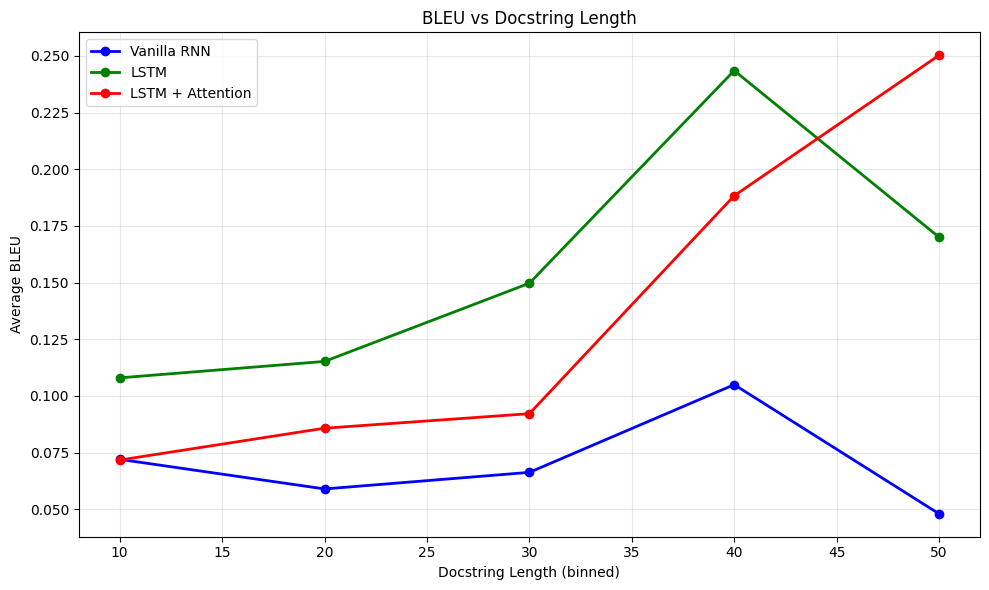

In [32]:
import matplotlib.pyplot as plt

model_map = {
    'Vanilla RNN': (model_rnn, 'rnn'),
    'LSTM': (model_lstm, 'lstm'),
    'LSTM + Attention': (model_attention, 'attention')
}

colors = ['blue', 'green', 'red']
fig, ax = plt.subplots(figsize=(10,6))

for (model_name, (model, model_type)), color in zip(model_map.items(), colors):
    print(f'Computing BLEU vs length: {model_name}...')
    lb = bleu_vs_length(model, model_type, test_data[:100], src_vocab, tgt_vocab, device, bin_size=10)
    bins = sorted(lb.keys())
    ax.plot(bins, [lb[b] for b in bins], marker='o', label=model_name, color=color, lw=2)

ax.set(
    xlabel='Docstring Length (binned)',
    ylabel='Average BLEU',
    title='BLEU vs Docstring Length'
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Attention Analysis

Generating attention visualizations...

--- Example 1 ---
Source: Make a character or block device called targetpath .
Target: def makedev ( self , tarinfo , targetpath ) : if not hasattr ( os , "mknod" ) or not hasattr ( os , "makedev" ) : raise ExtractError ( "special devices not supported by system" ) mode = tarinfo . mode if tarinfo . isblk ( ) : mode |= stat . S_IFBLK else : mode |= stat . S_IFCHR os . mknod ( targetpath , mode , os . makedev ( tarinfo . devmajor , tarinfo . devminor ) )
Predicted: def get_outputs ( self , : ) : return = self . self . self .


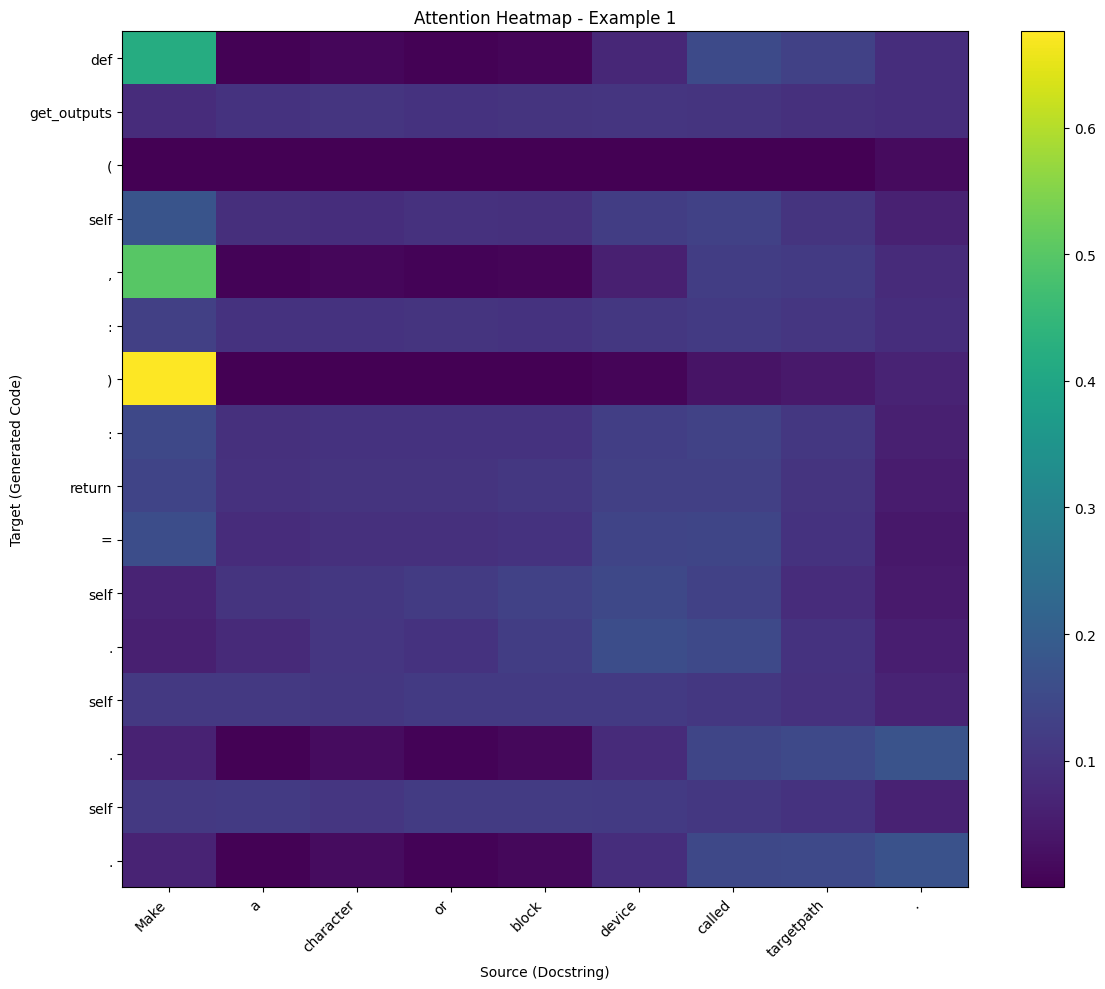


--- Example 2 ---
Source: Sort label names putting well - known resource labels first .
Target: def _sorted_resource_labels ( labels ) : head = [ label for label in TOP_RESOURCE_LABELS if label in labels ] tail = sorted ( label for label in labels if label not in TOP_RESOURCE_LABELS ) return head + tail
Predicted: def get_outputs ( self , : ) : return self . self . self .


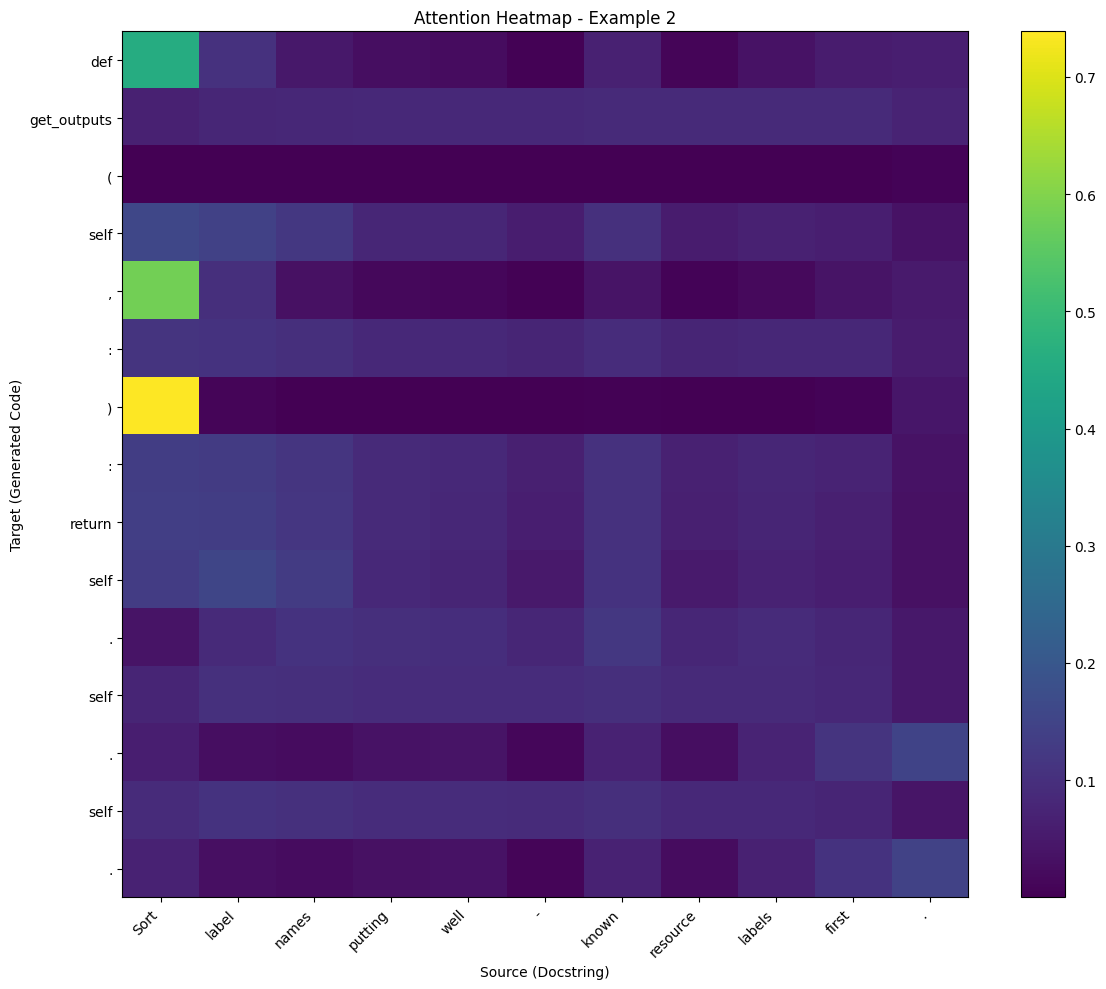


--- Example 3 ---
Source: : type root : TreeNode : type p : TreeNode : type q : TreeNode : rtype : TreeNode
Target: def lca ( root , p , q ) : if root is None or root is p or root is q : return root left = lca ( root . left , p , q ) right = lca ( root . right , p , q ) if left is not None and right is not None : return root return left if left else right
Predicted: def get_outputs ( self , : , : ) : if = . . ( ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) )


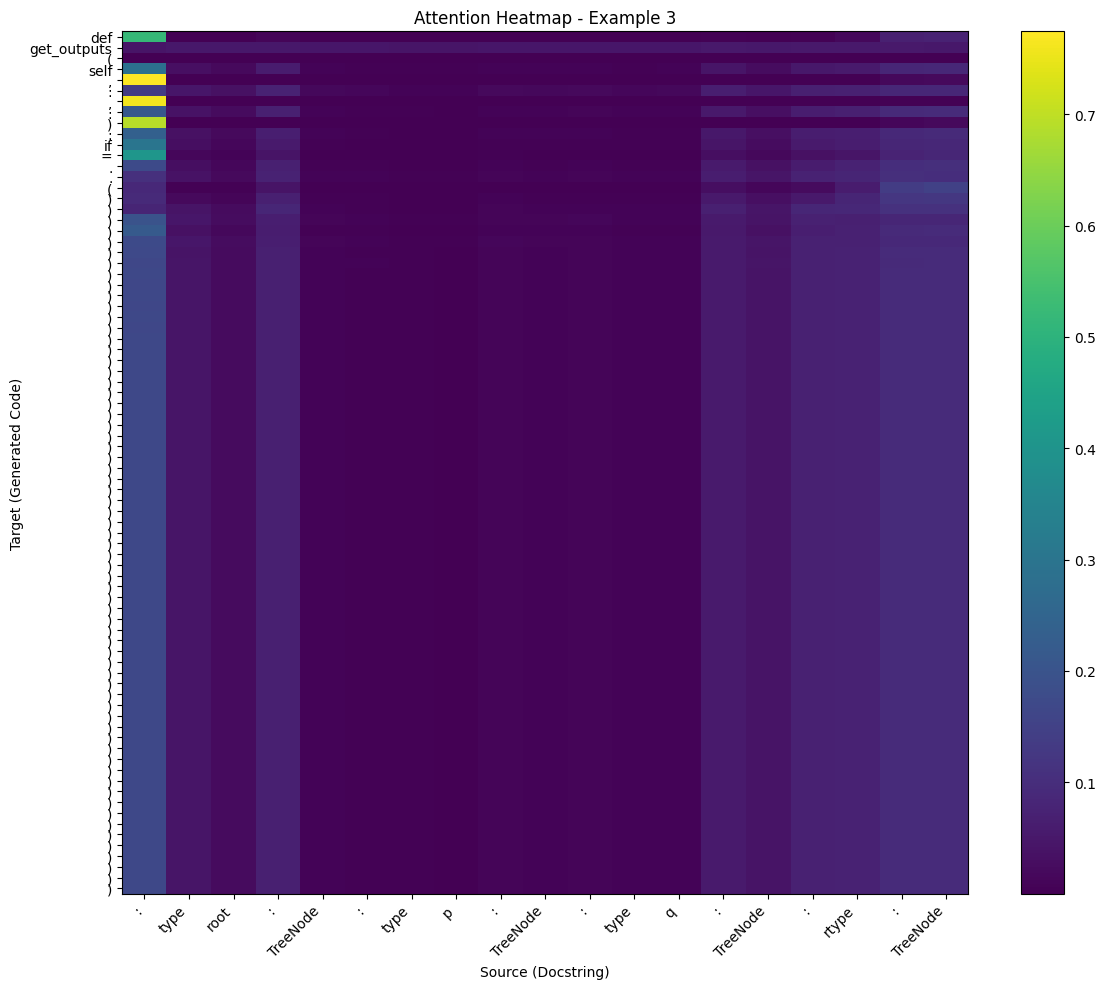


All visualizations saved to Google Drive!


In [ ]:
# Attention Visualization
def plot_attention(src_tokens, tgt_tokens, attention_weights, example_num):
    fig, ax = plt.subplots(figsize=(12, 10))

    attention = attention_weights[:len(tgt_tokens), :len(src_tokens)]

    im = ax.imshow(attention, cmap='viridis', aspect='auto')

    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right')
    ax.set_yticklabels(tgt_tokens)

    ax.set_xlabel('Source (Docstring)')
    ax.set_ylabel('Target (Generated Code)')
    ax.set_title(f'Attention Heatmap - Example {example_num}')

    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, f'attention_example_{example_num}.png'), dpi=300, bbox_inches='tight')
    plt.show()

print("Generating attention visualizations...")
for i in range(3):
    example = test_data[i]
    src = example['docstring']
    tgt = example['code']

    pred_indices, attention_weights = translate_sentence(
        model_attention, src, src_vocab, tgt_vocab, device, model_type='attention')

    src_tokens = src.split()
    pred_tokens = [tgt_vocab.idx2word.get(idx, '') for idx in pred_indices
                  if idx not in [SOS_IDX, EOS_IDX]
                  ]

    print(f"\n--- Example {i+1} ---")
    print(f"Source: {src}")
    print(f"Target: {tgt}")
    print(f"Predicted: {' '.join(pred_tokens)}")

    if attention_weights is not None and len(attention_weights) > 0:
        plot_attention(src_tokens, pred_tokens, attention_weights, i+1)

print("\nAll visualizations saved to Google Drive!")

### bonus

